## Premier League Match Outcome Predictor — Deep Learning (Win Probability)

This project predicts the probability of each outcome — **Home win / Draw / Away win** — for a match, using a PyTorch neural network.

### Important change from the original approach
The original models were trained on **full-time match statistics** (final goals, shots, cards, etc.). Those values only exist *after* a match is played and, in the case of final goals, literally define the result. Training on them causes **data leakage**: the model looks accurate but cannot predict a *future* match.

This version uses **only pre-match information**, derived from each team's history *before* kickoff:
- **Rolling form** over the last *N* games (goals for/against, shots, shots on target, corners, points).
- An **Elo rating** for each team, updated chronologically, with a home-field adjustment.

Models are evaluated with a **chronological split** (train on older matches, test on the most recent), which is the only honest way to measure a forecaster.

### Data
Public English Premier League data from https://www.football-data.co.uk/englandm.php — the last five seasons plus the current one. Place the season CSVs in a `DATA/` folder.

In [3]:
# Dependencies
import numpy as np
import pandas as pd
from collections import defaultdict, deque

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

In [4]:
# Load and combine seasons
csv_files = [
    "DATA/21-22.csv",
    "DATA/22-23.csv",
    "DATA/23-24.csv",
    "DATA/24-25.csv",
    "DATA/25-26.csv",
]

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Parse dates so matches can be ordered chronologically (essential to avoid leakage)
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")
df = df.dropna(subset=["Date", "HomeTeam", "AwayTeam", "FTR"]).reset_index(drop=True)

print("Combined shape:", df.shape)
df[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]].head()

Combined shape: (1680, 162)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,2021-08-13,Brentford,Arsenal,2,0,H
1,2021-08-14,Man United,Leeds,5,1,H
2,2021-08-14,Burnley,Brighton,1,2,A
3,2021-08-14,Chelsea,Crystal Palace,3,0,H
4,2021-08-14,Everton,Southampton,3,1,H


### Feature engineering — pre-match form + Elo

We walk through every match **in date order**. For each match we record features computed *only* from what happened in earlier matches, then update each team's rolling history and Elo rating **after** recording. This ordering guarantees no future information leaks into a row.

In [5]:
N_FORM   = 5     # number of recent games in the rolling form window
ELO_K    = 20    # Elo update speed
HOME_ADV = 60    # Elo points added to the home side

def build_features(df, n_form=N_FORM, elo_k=ELO_K, home_adv=HOME_ADV):
    df = df.sort_values("Date", kind="stable").reset_index(drop=True)
    teams = pd.unique(df[["HomeTeam", "AwayTeam"]].values.ravel())

    elo  = {t: 1500.0 for t in teams}
    hist = defaultdict(lambda: deque(maxlen=n_form))
    rows = []

    def form(team):
        h = hist[team]
        if not h:  # sensible neutral priors for a team with no history yet
            return dict(gf=1.2, ga=1.2, sf=12, sa=12, stf=4, sta=4, cf=5, ca=5, pts=1.0, n=0)
        agg = lambda k: float(np.mean([x[k] for x in h]))
        return dict(gf=agg("gf"), ga=agg("ga"), sf=agg("sf"), sa=agg("sa"),
                    stf=agg("stf"), sta=agg("sta"), cf=agg("cf"), ca=agg("ca"),
                    pts=agg("pts"), n=len(h))

    for _, m in df.iterrows():
        h, a = m["HomeTeam"], m["AwayTeam"]
        hf, af = form(h), form(a)
        eh, ea = elo[h], elo[a]
        exp_h = 1 / (1 + 10 ** (-((eh + home_adv) - ea) / 400))

        rows.append({
            "HomeTeam": h, "AwayTeam": a, "Date": m["Date"],
            "elo_diff": (eh + home_adv) - ea, "exp_home": exp_h,
            "h_gf": hf["gf"], "h_ga": hf["ga"], "a_gf": af["gf"], "a_ga": af["ga"],
            "gf_diff": hf["gf"] - af["gf"], "ga_diff": hf["ga"] - af["ga"],
            "h_sf": hf["sf"], "a_sf": af["sf"], "h_stf": hf["stf"], "a_stf": af["stf"],
            "h_cf": hf["cf"], "a_cf": af["cf"],
            "h_pts": hf["pts"], "a_pts": af["pts"], "pts_diff": hf["pts"] - af["pts"],
            "h_played": hf["n"], "a_played": af["n"],
            "FTR": m["FTR"],
        })

        # --- update state AFTER recording the row (prevents leakage) ---
        hg, ag = m["FTHG"], m["FTAG"]
        res = 1.0 if hg > ag else (0.0 if hg < ag else 0.5)
        elo[h] = eh + elo_k * (res - exp_h)
        elo[a] = ea + elo_k * ((1 - res) - (1 - exp_h))

        hp = 3 if hg > ag else (1 if hg == ag else 0)
        ap = 3 if ag > hg else (1 if hg == ag else 0)
        g = lambda k, d: m[k] if k in m and not pd.isna(m[k]) else d
        hist[h].append(dict(gf=hg, ga=ag, sf=g("HS",12), sa=g("AS",12),
                            stf=g("HST",4), sta=g("AST",4), cf=g("HC",5), ca=g("AC",5), pts=hp))
        hist[a].append(dict(gf=ag, ga=hg, sf=g("AS",12), sa=g("HS",12),
                            stf=g("AST",4), sta=g("HST",4), cf=g("AC",5), ca=g("HC",5), pts=ap))

    return pd.DataFrame(rows), elo, hist

feats, final_elo, final_hist = build_features(df)
print("Feature rows:", feats.shape)
feats.head()

Feature rows: (1680, 23)


,HomeTeam,AwayTeam,Date,elo_diff,exp_home,h_gf,h_ga,a_gf,a_ga,gf_diff,...,h_stf,a_stf,h_cf,a_cf,h_pts,a_pts,pts_diff,h_played,a_played,FTR
0,Brentford,Arsenal,2021-08-13,60.0,0.585499,1.2,1.2,1.2,1.2,0.0,...,4.0,4.0,5.0,5.0,1.0,1.0,0.0,0,0,H
1,Man United,Leeds,2021-08-14,60.0,0.585499,1.2,1.2,1.2,1.2,0.0,...,4.0,4.0,5.0,5.0,1.0,1.0,0.0,0,0,H
2,Burnley,Brighton,2021-08-14,60.0,0.585499,1.2,1.2,1.2,1.2,0.0,...,4.0,4.0,5.0,5.0,1.0,1.0,0.0,0,0,A
3,Chelsea,Crystal Palace,2021-08-14,60.0,0.585499,1.2,1.2,1.2,1.2,0.0,...,4.0,4.0,5.0,5.0,1.0,1.0,0.0,0,0,H
4,Everton,Southampton,2021-08-14,60.0,0.585499,1.2,1.2,1.2,1.2,0.0,...,4.0,4.0,5.0,5.0,1.0,1.0,0.0,0,0,H


### Prepare tensors and a chronological split

Because we are forecasting, the test set must be the **most recent** matches — never a random sample. We hold out the last 20% by date.

In [6]:
label_map = {"H": 0, "D": 1, "A": 2}
inv_label = {0: "Home Win", 1: "Draw", 2: "Away Win"}

feat_cols = [c for c in feats.columns if c not in ("HomeTeam", "AwayTeam", "Date", "FTR")]
X = feats[feat_cols].values.astype("float32")
y = feats["FTR"].map(label_map).values

cut = int(len(X) * 0.8)
X_train, X_test = X[:cut], X[cut:]
y_train, y_test = y[:cut], y[cut:]

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype("float32")
X_test  = scaler.transform(X_test).astype("float32")

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Features: {len(feat_cols)}")

Train: (1344, 19), Test: (336, 19), Features: 19


### The neural network

A small feed-forward network with dropout for regularisation. The final layer outputs three logits; a softmax turns them into the **win/draw/loss probabilities** you asked for. Class weights counter the natural imbalance (home wins are most common).

Epoch  50 | loss 1.0170
Epoch 100 | loss 0.9902
Epoch 150 | loss 0.9764
Epoch 200 | loss 0.9535
Epoch 250 | loss 0.9444
Epoch 300 | loss 0.9294
Epoch 350 | loss 0.9121
Epoch 400 | loss 0.9011


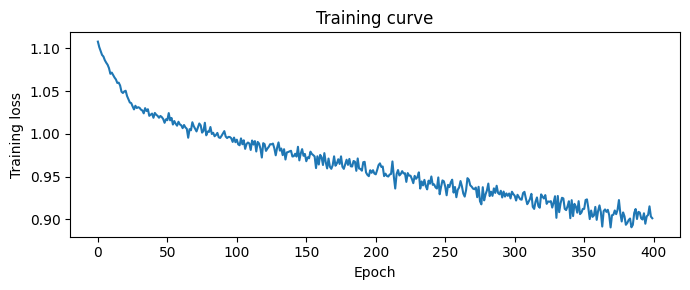

In [7]:
class MatchNet(nn.Module):
    def __init__(self, n_features, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)

model = MatchNet(len(feat_cols))

# class weights (inverse frequency) to stop the model ignoring draws
counts = np.bincount(y_train, minlength=3)
weights = torch.tensor((counts.sum() / (3 * counts)), dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

Xtr_t = torch.tensor(X_train); ytr_t = torch.tensor(y_train)
Xte_t = torch.tensor(X_test)

EPOCHS = 400
losses = []
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(Xtr_t), ytr_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3} | loss {loss.item():.4f}")

plt.figure(figsize=(7,3))
plt.plot(losses); plt.xlabel("Epoch"); plt.ylabel("Training loss")
plt.title("Training curve"); plt.tight_layout(); plt.show()

### Evaluation on the held-out (most recent) matches

Accuracy alone is misleading for a 3-way probabilistic forecast, so we also report **log-loss** (rewards well-calibrated probabilities) and compare against a naive always-predict-Home baseline. For Premier League football, ~50–55% accuracy is genuinely strong — bookmakers operate in the same range.

Neural net accuracy : 0.464
Neural net log-loss : 1.048
Baseline (all Home) : 0.455


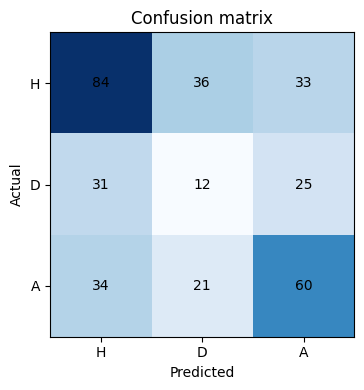

In [8]:
model.eval()
with torch.no_grad():
    test_probs = torch.softmax(model(Xte_t), dim=1).numpy()
test_pred = test_probs.argmax(1)

acc  = accuracy_score(y_test, test_pred)
ll   = log_loss(y_test, test_probs, labels=[0,1,2])
base = accuracy_score(y_test, [0]*len(y_test))

print(f"Neural net accuracy : {acc:.3f}")
print(f"Neural net log-loss : {ll:.3f}")
print(f"Baseline (all Home) : {base:.3f}")

cm = confusion_matrix(y_test, test_pred, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(4.5,4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(["H","D","A"]); ax.set_yticklabels(["H","D","A"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha="center", va="center")
plt.tight_layout(); plt.show()

### Predicting a fixture

`predict_match` rebuilds the pre-match feature vector for a hypothetical fixture from each team's **current** form and Elo (the state at the end of the dataset), then returns calibrated probabilities — the *percent chance* of each outcome.

In [ ]:
def predict_match(home_team, away_team, n_form=N_FORM, home_adv=HOME_ADV):
    for t in (home_team, away_team):
        if t not in final_elo:
            return f"Team not found: {t!r}. Check spelling (e.g. \"Man City\", \"Nott\'m Forest\")."

    def form(team):
        h = final_hist[team]
        if not h:
            return dict(gf=1.2, ga=1.2, sf=12, sa=12, stf=4, sta=4, cf=5, ca=5, pts=1.0, n=0)
        agg = lambda k: float(np.mean([x[k] for x in h]))
        return dict(gf=agg("gf"), ga=agg("ga"), sf=agg("sf"), sa=agg("sa"),
                    stf=agg("stf"), sta=agg("sta"), cf=agg("cf"), ca=agg("ca"),
                    pts=agg("pts"), n=len(h))

    hf, af = form(home_team), form(away_team)
    eh, ea = final_elo[home_team], final_elo[away_team]
    exp_h = 1 / (1 + 10 ** (-((eh + home_adv) - ea) / 400))

    row = {
        "elo_diff": (eh + home_adv) - ea, "exp_home": exp_h,
        "h_gf": hf["gf"], "h_ga": hf["ga"], "a_gf": af["gf"], "a_ga": af["ga"],
        "gf_diff": hf["gf"] - af["gf"], "ga_diff": hf["ga"] - af["ga"],
        "h_sf": hf["sf"], "a_sf": af["sf"], "h_stf": hf["stf"], "a_stf": af["stf"],
        "h_cf": hf["cf"], "a_cf": af["cf"],
        "h_pts": hf["pts"], "a_pts": af["pts"], "pts_diff": hf["pts"] - af["pts"],
        "h_played": hf["n"], "a_played": af["n"],
    }
    x = np.array([[row[c] for c in feat_cols]], dtype="float32")
    x = scaler.transform(x).astype("float32")

    model.eval()
    with torch.no_grad():
        p = torch.softmax(model(torch.tensor(x)), dim=1).numpy()[0]

    return {
        f"{home_team} win": round(float(p[0]) * 100, 1),
        "Draw":             round(float(p[1]) * 100, 1),
        f"{away_team} win": round(float(p[2]) * 100, 1),
    }

# Example
home = input("Enter Home Team: ").strip()
away = input("Enter Away Team: ").strip()
result = predict_match(home, away)
print(f"\nPrediction for {home} vs {away}:")
if isinstance(result, dict):
    for outcome, pct in result.items():
        print(f"  {outcome:<20} {pct:>5.1f}%")
else:
    print(result)

### Notes and possible extensions
- **Tune `N_FORM`, `ELO_K`, `HOME_ADV`** — reasonable starting points, not optimised. A small grid search on the validation period will help.
- **Bookmaker odds** (`B365H/D/A`) are strong features if you want to *beat* or *blend with* the market; they were deliberately excluded here so the model learns from football data alone.
- **Calibration**: for betting-grade probabilities, apply temperature scaling or isotonic regression on a validation split.
- **More data**: extending beyond five seasons and adding promoted-team handling will improve robustness.